In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

source_parquet = '../../food.parquet'

In [2]:
liste_cols = [
    'additives_n',
    'additives_tags',
    'allergens_tags',
    'brands_tags',
    'brands',
    'categories',
    'categories_tags',
    'categories_properties',
    'checkers_tags',
    'ciqual_food_name_tags',
    #'code',# df base
    'compared_to_category',
    'complete',
    'completeness',
    #'correctors_tags',# trop lourd
    #'countries_tags',# df base
    'created_t',
    'creator',
    'data_quality_errors_tags',
    'data_quality_info_tags',
    'data_quality_warnings_tags',
    'data_sources_tags',
    #'environmental_score_data',# trop lourd
    'environmental_score_grade',
    'environmental_score_score',
    'environmental_score_tags',
    'editors',
    'emb_codes_tags',
    'emb_codes',
    'entry_dates_tags',
    'food_groups_tags',
    'generic_name',
    #'images',# trop lourd
    'informers_tags',
    'ingredients_analysis_tags',
    'ingredients_from_palm_oil_n',
    'ingredients_n',
    'ingredients_original_tags',
    'ingredients_percent_analysis',
    'ingredients_tags',
    'ingredients_text',
    'ingredients_with_specified_percent_n',
    'ingredients_with_unspecified_percent_n',
    'ingredients_without_ciqual_codes_n',
    'ingredients_without_ciqual_codes',
    #'ingredients',# trop lourd
    'known_ingredients_n',
    'labels_tags',
    'labels',
    'lang',
    'languages_tags',
    'last_edit_dates_tags',
    'last_editor',
    'last_image_t',
    'last_modified_by',
    'last_modified_t',
    'last_updated_t',
    'link',
    'main_countries_tags',
    'manufacturing_places_tags',
    'manufacturing_places',
    'max_imgid',
    'minerals_tags',
    'misc_tags',
    'new_additives_n',
    'no_nutrition_data',
    'nova_group',
    'nova_groups_tags',
    'nova_groups',
    'nucleotides_tags',
    'nutrient_levels_tags',
    #'nutriments',# trop lourd
    'nutriscore_grade',
    'nutriscore_score',
    'nutrition_data_per',
    'obsolete',
    'origins_tags',
    'origins',
    'owner_fields',
    'owner',
    'packagings_complete',
    'packaging_recycling_tags',
    'packaging_shapes_tags',
    'packaging_tags',
    'packaging_text',
    'packaging',
    'packagings',
    'photographers',
    'popularity_key',
    'popularity_tags',
    'product_name',
    'product_quantity_unit',
    'product_quantity',
    'purchase_places_tags',
    'quantity',
    'rev',
    'scans_n',
    'serving_quantity',
    'serving_size',
    'states_tags',
    'stores_tags',
    'stores',
    'traces_tags',
    'unique_scans_n',
    'unknown_ingredients_n',
    'unknown_nutrients_tags',
    'vitamins_tags',
    'with_non_nutritive_sweeteners',
    'with_sweeteners'
]

In [3]:
def baseProcess(colonnes):
    print(f"*** {list(map(str.upper, colonnes))} ***")

    use_cols = ["code", "countries_tags"] + colonnes

    df = pd.read_parquet(
        source_parquet,
        engine="pyarrow",
        columns=use_cols
    )

    # doublons code
    df = df.drop_duplicates(subset=["code"])

    # suppression valeurs manquantes countries_tags
    df = df.dropna(subset=["countries_tags"])
    
    # filtre vendu france
    filtre = df['countries_tags'].apply(lambda x: 'en:france' in x)
    df_france = df[filtre]
    print(f"Dimensions : {df_france.shape}")
    print(f"→ {df_france.shape[0]} lines, {df_france.shape[1]} columns")

    return df_france

def _obtenir_type_logique(series):
    non_na = series.dropna()
    if non_na.empty:
        return "vide"
    premier_element = non_na.iloc[0]
    if isinstance(premier_element, dict):
        return "dictionnaire"
    if isinstance(premier_element, (list, np.ndarray, set)):
        return "liste"
    if pd.api.types.is_numeric_dtype(series):
        return "numerique"

    return "categoriel"

def distribution_speciale(df, colonne, graph=False):
    print('\nDISTRIBUTIONS\n')

    type_col = _obtenir_type_logique(df[colonne])

    df_elements = df[colonne].explode().dropna()
    
    if type_col == "liste":

        # --- AJUSTEMENT POUR LES LISTES DE DICTIONNAIRES ---
        # On vérifie si les éléments extraits de la liste sont des dictionnaires
        premier_element = df_elements.iloc[0] if not df_elements.empty else None
        
        if isinstance(premier_element, dict):
            # Si c'est un dictionnaire (ex: {'lang': 'fr', 'text': 'assaisonnement'})
            # On extrait uniquement la valeur textuelle pour calculer le mode
            # On cherche d'abord la clé 'text', sinon 'name', sinon la première clé disponible
            cle_texte = 'text' if 'text' in premier_element else ('name' if 'name' in premier_element else list(premier_element.keys())[0])
            
            df_elements_traites = df_elements.apply(lambda x: x.get(cle_texte) if isinstance(x, dict) else x).dropna()
            label_type = f"Liste de Dicts (clé: '{cle_texte}')"
        else:
            # Si c'est une liste standard (chaînes, nombres, etc.)
            df_elements_traites = df_elements
            label_type = "Liste standard"

        # --- CALCUL DU MODE ---
        mode_series = df_elements_traites.mode()
        mode_val = mode_series.iloc[0] if not mode_series.empty else 'N/A'
        print(f"Type : {label_type} | Mode : {mode_val}")

        # --- GRAPHIQUE ---
        if graph and not df_elements_traites.empty:
            plt.figure(figsize=(9, 4))
            df_elements_traites.value_counts().head(10).plot(kind='bar', color='darkgreen')
            plt.title(f'Top 10 des éléments de {colonne}')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

    elif type_col == "dict":
        df_dicts = df[colonne].dropna()
        cles = df_dicts.apply(lambda x: list(x.keys()) if isinstance(x, dict) else []).explode()
        print(f"Type : Dictionnaire | Nb clés uniques : {cles.nunique()} | Clé la plus fréquente : {cles.mode().iloc[0] if not cles.mode().empty else 'N/A'}")

        if graph and not cles.empty:
            plt.figure(figsize=(9, 4))
            cles.value_counts().head(10).plot(kind='bar', color='darkgreen')
            plt.title(f'Top 10 des clés les plus fréquentes dans {colonne}')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
        
    elif type_col == "numerique":
        # --- Tendance Centrale ---
        print("--- Tendance Centrale ---")
        print(f"Moyenne : {df[colonne].mean():.2f}")
        print(f"Médiane : {df[colonne].median():.2f}")
        mode_val = df[colonne].mode()
        print(f"Mode (Valeur la plus fréquente) : {mode_val.iloc[0] if not mode_val.empty else 'N/A'}")

        # --- Dispersion ---
        print("\n--- Dispersion ---")
        print(f"Écart-type : {df[colonne].std():.2f}")
        print(f"Minimum : {df[colonne].min():.2f}")
        print(f"Maximum : {df[colonne].max():.2f}")

        # --- Forme de la distribution ---
        print("\n--- Forme de la distribution ---")
        print(f"Skewness (Asymétrie) : {df[colonne].skew():.2f}")

        if graph:
            plt.figure(figsize=(9, 4))
            sns.histplot(df[colonne].dropna(), bins=30, kde=True, color='darkgreen')
            plt.title(f'Distribution de {colonne}')
            plt.tight_layout()
            plt.show()
        
    else:
        print(f"Type : Catégoriel | Mode : {df[colonne].mode().iloc[0] if not df[colonne].mode().empty else 'N/A'}")

        if graph:
            plt.figure(figsize=(9, 4))
            df[colonne].value_counts().head(10).plot(kind='bar', color='darkgreen')
            plt.title(f'Top 10 de {colonne}')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

def cardinalite(df, colonne):
    print('\nCARDINALITES')
    total_lignes = len(df)

    print(f"\n--- Métriques de {colonne} ---")
    type_col = _obtenir_type_logique(df[colonne])
    valeurs_manquantes = df[colonne].isna().sum()
    pct_manquants = (valeurs_manquantes / total_lignes * 100) if total_lignes > 0 else 0
    
    if type_col == "liste":
        df_elements = df[colonne].explode().dropna()
        
        # --- AJUSTEMENT POUR LES LISTES DE DICTIONNAIRES ---
        premier_element = df_elements.iloc[0] if not df_elements.empty else None
        
        if isinstance(premier_element, dict):
            # Si c'est un dictionnaire, on extrait la valeur textuelle pour pouvoir la hacher/compter
            cle_texte = 'text' if 'text' in premier_element else ('name' if 'name' in premier_element else list(premier_element.keys())[0])
            cardinalite = df_elements.apply(lambda x: x.get(cle_texte) if isinstance(x, dict) else x).dropna().nunique()
        else:
            # Liste standard d'éléments hachables (str, int, etc.)
            cardinalite = df_elements.nunique()
            
    elif type_col == "dict":
        cardinalite = df[colonne].dropna().apply(lambda x: list(x.keys()) if isinstance(x, dict) else []).explode().nunique()
    else:
        try:
            cardinalite = df[colonne].nunique()
        except TypeError:
            # Sécurité si la colonne contient des dicts/listes non détectés par _obtenir_type_logique
            cardinalite = df[colonne].astype(str).nunique()
        
    taux_cardinalite = (cardinalite / total_lignes) * 100 if total_lignes > 0 else 0

    print(f"Nombre total de lignes : {total_lignes}")
    print(f"Manquants : {valeurs_manquantes} ({pct_manquants:.2f}%)")
    print(f"Cardinalité absolue (Nombre de {colonne} uniques): {cardinalite}")
    print(f"Taux de cardinalité : {taux_cardinalite:.2f}%")



def generer_rapport_ml(df, colonne):
    # ==================== RAPPORT DÉCISIONNEL MACHINE LEARNING ====================
    total_lignes = len(df)
    
    valeurs_manquantes = df[colonne].isna().sum()
    pct_manquants = (valeurs_manquantes / total_lignes * 100) if total_lignes > 0 else 0

    type_col = _obtenir_type_logique(df[colonne])


    # --- GESTION DE LA CARDINALITÉ SELON LE TYPE ---
    if type_col in ["dict", "dictionnaire"]:
        # Extraction sécurisée des clés sous forme de liste pour éviter le problème de hachage
        cles_series = df[colonne].dropna().apply(lambda x: list(x.keys()) if isinstance(x, dict) else [])
        cardinalite = cles_series.explode().nunique()
        
    elif type_col == "liste":
        # Si la liste contient des dictionnaires, explode() + nunique() provoquera la même erreur.
        # On convertit les éléments non hachables en string par sécurité.
        valeurs_explosees = df[colonne].explode().dropna()
        if valeurs_explosees.astype(str).str.startswith('{').any():
            cardinalite = valeurs_explosees.astype(str).nunique()
        else:
            cardinalite = valeurs_explosees.nunique()
        
    else:
        try:
            cardinalite = df[colonne].nunique()
        except TypeError:
            # Sécurité globale : si Pandas trouve un dictionnaire caché dans un type standard
            cardinalite = df[colonne].astype(str).nunique()

        
    taux_cardinalite = (cardinalite / total_lignes) * 100 if total_lignes > 0 else 0
    
    print(f"\n📈 [RAPPORT] Colonne '{colonne}' ({type_col}) :")
    
    # --- LOGIQUE DE DÉCISION ML ---
    if pct_manquants > 40:
        print(f"❌ REJETÉE. Avec {pct_manquants:.1f}% de valeurs manquantes, le niveau d'information est insuffisant.")
        
    elif cardinalite <= 1 and type_col != "dictionnaire":
        # Note : Un dictionnaire vide ou avec 1 seule clé peut quand même être étendu, 
        # mais la règle de variance nulle reste vraie pour les autres types.
        print(f"❌ REJETÉE. La variance est nulle ou quasi-nulle (cardinalité de {cardinalite}).")
        
    elif type_col == "categoriel" and taux_cardinalite > 30:
        print(f"⚠️ À REFORMATER / REJET EN L'ÉTAT. La cardinalité est trop élevée ({cardinalite} modalités uniques).")
        
    elif type_col == "liste":
        print(f"✅ CONSERVÉE (Feature Engineering requis). Type [liste] exploitable avec {cardinalite} éléments uniques.")
        
    elif type_col == "dictionnaire":
        print(f"✅ CONSERVÉE (Feature Engineering requis). Type [dictionnaire] contenant {cardinalite} clés uniques.")
        
    else:
        print(f"✅ CONSERVÉE. Le taux de complétude ({100-pct_manquants:.1f}%) et la variance sont optimaux.")

    print("-" * 80)

In [5]:
for col in liste_cols:
    df = baseProcess([col])
    distribution_speciale(df, col)
    cardinalite(df, col)
    generer_rapport_ml(df, col)

*** ['ADDITIVES_N'] ***
Dimensions : (1247309, 3)
→ 1247309 lines, 3 columns

DISTRIBUTIONS

--- Tendance Centrale ---
Moyenne : 1.53
Médiane : 1.00
Mode (Valeur la plus fréquente) : 0.0

--- Dispersion ---
Écart-type : 2.37
Minimum : 0.00
Maximum : 289.00

--- Forme de la distribution ---
Skewness (Asymétrie) : 7.31

CARDINALITES

--- Métriques de additives_n ---
Nombre total de lignes : 1247309
Manquants : 888427 (71.23%)
Cardinalité absolue (Nombre de additives_n uniques): 35
Taux de cardinalité : 0.00%

📈 [RAPPORT] Colonne 'additives_n' (numerique) :
❌ REJETÉE. Avec 71.2% de valeurs manquantes, le niveau d'information est insuffisant.
--------------------------------------------------------------------------------
*** ['ADDITIVES_TAGS'] ***
Dimensions : (1247309, 3)
→ 1247309 lines, 3 columns

DISTRIBUTIONS

Type : Liste standard | Mode : en:e330

CARDINALITES

--- Métriques de additives_tags ---
Nombre total de lignes : 1247309
Manquants : 888287 (71.22%)
Cardinalité absolue (Nomb

In [12]:
liste_cols_speciale = [
    'correctors_tags',
    'environmental_score_data',
    'images',
    'ingredients',
    'nutriments'
]

In [13]:
for col in liste_cols_speciale:
    df = baseProcess([col])
    distribution_speciale(df, col)
    cardinalite(df, col)
    generer_rapport_ml(df, col)

*** ['CORRECTORS_TAGS'] ***
Dimensions : (1247309, 3)
→ 1247309 lines, 3 columns

DISTRIBUTIONS

Type : Liste standard | Mode : openfoodfacts-contributors

CARDINALITES

--- Métriques de correctors_tags ---
Nombre total de lignes : 1247309
Manquants : 0 (0.00%)
Cardinalité absolue (Nombre de correctors_tags uniques): 394574
Taux de cardinalité : 31.63%

📈 [RAPPORT] Colonne 'correctors_tags' (liste) :
✅ CONSERVÉE (Feature Engineering requis). Type [liste] exploitable avec 394574 éléments uniques.
--------------------------------------------------------------------------------
*** ['ENVIRONMENTAL_SCORE_DATA'] ***
Dimensions : (1247309, 3)
→ 1247309 lines, 3 columns

DISTRIBUTIONS

Type : Catégoriel | Mode : {"adjustments":{"origins_of_ingredients":{"aggregated_origins":[{"origin":"en:algeria","percent":100}],"transportation_values":{"cz":3,"gr":9,"uk":6,"eg":7,"bg":5,"md":6,"xk":8,"es":7,"se":5,"lt":4,"rs":6,"fi":5,"lv":6,"li":8,"sy":6,"mt":3,"tr":3,"hr":8,"sk":4,"tn":9,"ie":8,"hu":5,"cy

In [ ]:
# Autres analyses:

*** ['NUTRISCORE_SCORE', 'NUTRISCORE_GRADE', 'NUTRIMENTS'] ***
Dimensions : (1247309, 5)
→ 1247309 lines, 5 columns


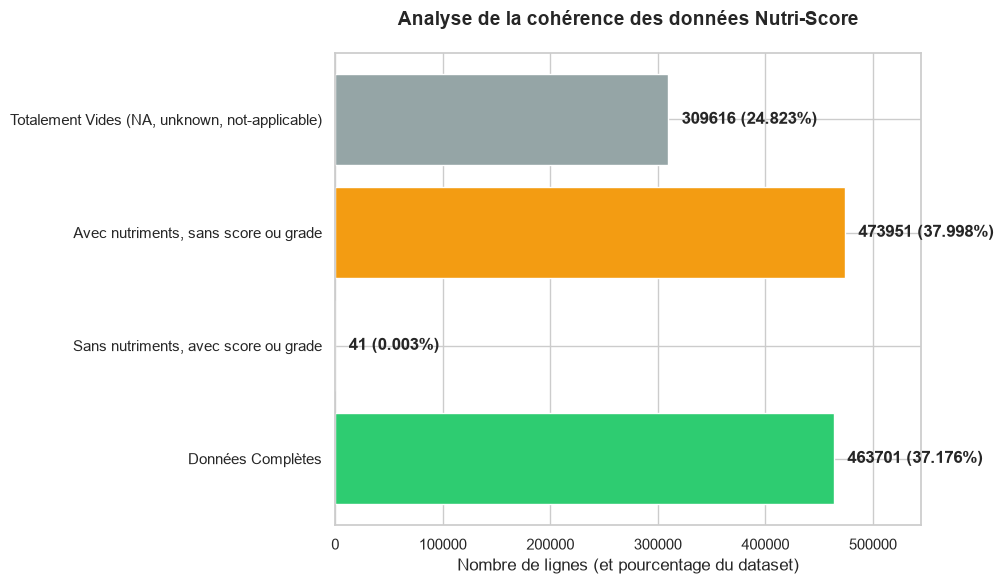

In [7]:
# nutriscore_score, nutriscore_grade, nutriments

df = baseProcess(['nutriscore_score', 'nutriscore_grade', 'nutriments'])

total_lignes = len(df)

# Définition de la condition "vide ou invalide" pour le grade
grade_vide = (
    df["nutriscore_grade"].isna()
    | df["nutriscore_grade"].isin(["unknown", "not-applicable"])
)
grade_present = ~grade_vide

# Catégorie A : Complètes (Nutriments ET Score ET Grade présents)
completes = (
    df["nutriments"].notna()
    & df["nutriscore_score"].notna()
    & grade_present
).sum()

# Catégorie B : Totalement vides (Aucune des 3 variables)
vides = (
    df["nutriments"].isna()
    & df["nutriscore_score"].isna()
    & grade_vide
).sum()

# Incohérences
incoherence_1 = (
    df["nutriments"].isna()
    & (df["nutriscore_score"].notna() | grade_present)
).sum()

incoherence_2 = (
    df["nutriments"].notna()
    & (df["nutriscore_score"].isna() | grade_vide)
).sum()

categories = [
    "Données Complètes",
    "Sans nutriments, avec score ou grade",
    "Avec nutriments, sans score ou grade",
    "Totalement Vides (NA, unknown, not-applicable)",
]
valeurs = [completes, incoherence_1, incoherence_2, vides]

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

colors = ["#2ecc71", "#e74c3c", "#f39c12", "#95a5a6"]
bars = plt.barh(categories, valeurs, color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (total_lignes * 0.01),  # Décalage horizontal
        bar.get_y() + bar.get_height() / 2,  # Centrage vertical
        f"{int(width)} ({width/total_lignes:.3%})",
        va="center",
        ha="left",
        fontweight="bold",
    )

plt.title(
    "Analyse de la cohérence des données Nutri-Score",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Nombre de lignes (et pourcentage du dataset)")
plt.xlim(0, max(valeurs) * 1.15)
plt.tight_layout()

plt.show()

*** ['NUTRISCORE_GRADE'] ***
Dimensions : (1247309, 3)
→ 1247309 lines, 3 columns
Nombre de valeurs manquantes (NaN) : 25037 | 2.01%
Nombre de valeurs manquantes (unknown) : 717590 | 57.53%
Nombre de valeurs manquantes (not-applicable) : 40940 | 3.28%


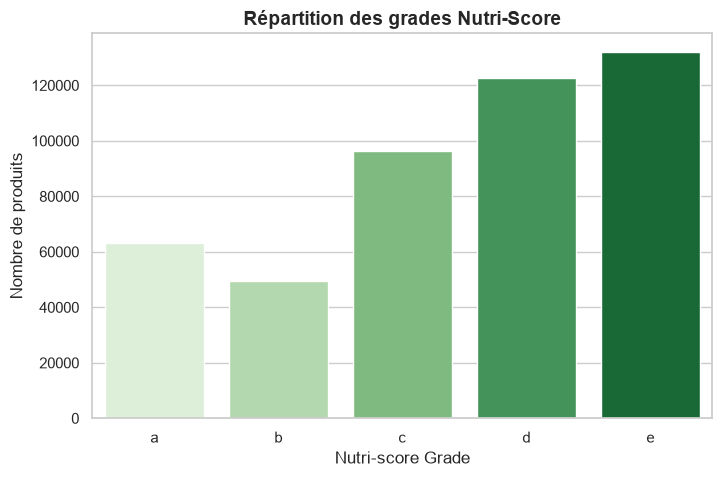

--- Fréquences des catégories ---
nutriscore_grade
e    28.495370
d    26.421588
c    20.784833
a    13.609723
b    10.688486
Name: proportion, dtype: float64


In [8]:
# nutriscore_grade

df = baseProcess(['nutriscore_grade'])

total_initial = len(df)

exclusions = ["unknown", "not-applicable"]

for categorie in ["NaN"] + exclusions:
    if categorie == "NaN":
        nb = df["nutriscore_grade"].isna().sum()
    else:
        nb = df["nutriscore_grade"].str.lower().eq(categorie).sum()

    pct = round((nb / total_initial * 100), 2)
    print(f"Nombre de valeurs manquantes ({categorie}) : {nb} | {pct}%")

df = df.dropna(subset=["nutriscore_grade"])
df = df[~df["nutriscore_grade"].str.lower().isin(exclusions)]

plt.figure(figsize=(8, 5))

ordre_grades = ["a", "b", "c", "d", "e"]
ordre_existant = [g for g in ordre_grades if g in df["nutriscore_grade"].str.lower().values]

sns.countplot(
    data=df,
    x="nutriscore_grade",
    hue="nutriscore_grade",

    order=ordre_existant,
    palette="Greens_r",
)

plt.title("Répartition des grades Nutri-Score", fontsize=14, fontweight="bold")
plt.xlabel("Nutri-score Grade", fontsize=12)
plt.ylabel("Nombre de produits", fontsize=12)
plt.show()

print("--- Fréquences des catégories ---")
print(df["nutriscore_grade"].str.lower().value_counts(normalize=True) * 100)

In [10]:
# Nutriments

df = baseProcess(['nutriments'])

df = df.dropna(subset=['nutriments'])

# mapping clé => valeur dictionnaire nutriments
extracted_data = [{item['name']: item['100g'] for item in row} for row in df['nutriments']]
df = df.join(pd.DataFrame(extracted_data, index=df.index))

*** ['NUTRIMENTS'] ***
Dimensions : (1247309, 3)
→ 1247309 lines, 3 columns


Nombre de colonnes: 170
colonnes non vide: 145


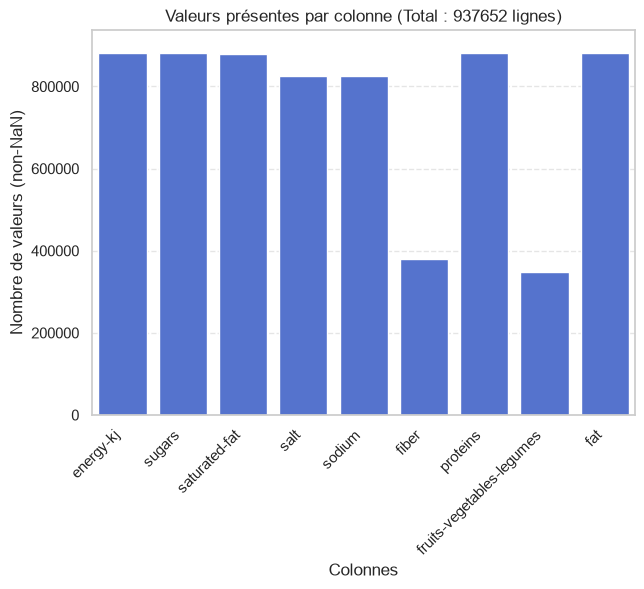

In [11]:
liste_col = list(df.columns)
colonnes_cibles = liste_col[3::]

print(f"Nombre de colonnes: {len(colonnes_cibles)}")

valeurs_presentes = df[colonnes_cibles].notna().sum()
total_lignes = len(df)

valeurs_presentes = valeurs_presentes[valeurs_presentes > 0]
print(f"colonnes non vide: {len(valeurs_presentes)}")

#with pd.option_context('display.max_rows', None):
    #display(valeurs_presentes.sort_values(ascending=False))

# Colonnes utiles pour les calculs Nutriscore si la donnée est maquante
# /!\ salt ou sodium
colonnes_cibles = ['energy-kj', 'sugars', 'saturated-fat', 'salt', 'sodium', 'fiber', 'proteins', 'fruits-vegetables-legumes', 'fat']
valeurs_presentes = df[colonnes_cibles].notna().sum()
total_lignes = len(df)


plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=valeurs_presentes.index, y=valeurs_presentes.values, color="royalblue"
)

plt.title(
    f"Valeurs présentes par colonne (Total : {total_lignes} lignes)",
    fontsize=12,
)
plt.ylabel("Nombre de valeurs (non-NaN)")
plt.xlabel("Colonnes")

plt.xticks(rotation=45, ha="right")

plt.ylim(0, total_lignes)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()